<a href="https://colab.research.google.com/github/YiranLiu314/emotion-classification/blob/main/Emotion_Research_Alaina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Track 2: Natural Language Processing (Text)

**Program Context:** Multimodal Emotion Recognition Summer Research Program

**Colab Instructions:** To run this notebook in Google Colab, click the badge in the README or upload the file to your Google Drive, right-click, and select 'Open with Google Colaboratory'.

Fill in every cell marked `TODO`. Run cells top to bottom.

## 0. Install and import

In [ ]:
# Import standard Python tools for text processing.
import re
import string

# Import data analysis and visualization libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import NLP tools and machine learning models.
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Download the English stop-word list used during text cleaning.
nltk.download("stopwords", quiet=True)


/Users/aria/Desktop/calpolyresearch/project-2-text/.venv/lib/python3.12/site-packages/nltk/downloader.py:980: RuntimeWarning: Security Violation [pathsec.urlopen]: SSRF attempt to restricted IP 198.18.0.163
  ElementTree.parse(urlopen(self._url)).getroot()


True

## 1. Week 2 -- Load Dataset

Load your text dataset into a pandas DataFrame. Extract the raw text and labels.

In [ ]:
# Path to the prepared dataset file inside the project.
DATA_PATH = "data/twitter_emotion.csv"

# Load the CSV into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Print basic dataset information to confirm the file loaded correctly.
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nColumns:", list(df.columns))
print("\nMissing values:")
print(df.isna().sum())

# Remove rows missing the two required columns and standardize their types.
df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

# Store the raw text and labels for later steps.
texts = df["text"]
labels = df["label"]

# Check whether the target classes are balanced or imbalanced.
print("\nLabel distribution:")
display(df["label"].value_counts().to_frame("count"))

# Check the class distribution inside train, validation, and test splits.
if "split" in df.columns:
    print("\nSplit distribution:")
    display(pd.crosstab(df["split"], df["label"]))

# Display the first few rows to inspect the raw dataset.
display(df.head())


Dataset shape: 416,809 rows x 4 columns

Columns: ['text', 'label', 'label_id', 'split']

Missing values:
text        0
label       0
label_id    0
split       0
dtype: int64

Label distribution:


,count
label,
joy,141067
sadness,121187
anger,57317
fear,47712
love,34554
surprise,14972



Split distribution:


label,anger,fear,joy,love,sadness,surprise
split,,,,,,
test,5775,4835,13974,3476,12182,1439
train,45877,38208,112899,27580,96802,12081
validation,5665,4669,14194,3498,12203,1452


,text,label,label_id,split
0,i didn t feel rushed to finish millions of thi...,anger,3,train
1,i don t know how to feel valuable within myself,joy,1,train
2,i feel so helpless depressed in the current si...,sadness,0,train
3,i am feeling gloomy unmotivated and overwhelmed,sadness,0,train
4,i feel utterly unsure of what career path to c...,fear,4,train


## 2. Week 3 -- Clean Text

Clean the raw text to prepare it for the model. This typically involves converting to lowercase, removing punctuation, and removing common stop words.

In [ ]:
# Create a set of common English words to remove from the text.
STOP_WORDS = set(stopwords.words("english"))


def clean_text(text):
    # Lowercase text so words like "Happy" and "happy" are treated the same.
    text = text.lower()
    # Remove URLs and usernames because they usually do not help emotion prediction.
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    # Remove hashtag symbols but keep the hashtag word itself.
    text = re.sub(r"#", "", text)
    # Remove punctuation, numbers, and extra spaces.
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stop words such as "the", "and", and "is".
    tokens = [word for word in text.split() if word not in STOP_WORDS]
    return " ".join(tokens)


# Apply the cleaning function to every text sample.
df["clean_text"] = df["text"].apply(clean_text)

# Drop rows where cleaning removed all usable words.
df = df[df["clean_text"].str.len() > 0].copy()

# Save cleaned text and labels for feature extraction and modeling.
clean_texts = df["clean_text"]
labels = df["label"]

print(f"Rows after cleaning: {len(df):,}")
display(df[["text", "clean_text", "label", "split"]].head(10))


Rows after cleaning: 416,793


,text,clean_text,label,split
0,i didn t feel rushed to finish millions of thi...,feel rushed finish millions things able focus ...,anger,train
1,i don t know how to feel valuable within myself,know feel valuable within,joy,train
2,i feel so helpless depressed in the current si...,feel helpless depressed current situation coul...,sadness,train
3,i am feeling gloomy unmotivated and overwhelmed,feeling gloomy unmotivated overwhelmed,sadness,train
4,i feel utterly unsure of what career path to c...,feel utterly unsure career path choose feel wo...,fear,train
5,i feel like a fake dressed in the closest appr...,feel like fake dressed closest approximation m...,sadness,train
6,i know i inherited and unfortunately passed on...,know inherited unfortunately passed daughter o...,sadness,train
7,i know is not true for all circumstances and a...,know true circumstances people feel like would...,joy,train
8,i at least cant imagine my friends having peop...,least cant imagine friends people house making...,sadness,train
9,i feel what i feel so let me feel what i want ...,feel feel let feel want feelings foolish child...,sadness,train


## 3. Week 4 -- Feature Extraction (TF-IDF)

Convert the cleaned text into numerical features using Term Frequency-Inverse Document Frequency (TF-IDF).

In [ ]:
# Convert cleaned text into TF-IDF features.
# TF-IDF gives higher weight to words that are important in a document but not too common overall.
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(
    max_features=10000,      # Limit vocabulary size to keep training efficient.
    ngram_range=(1, 2),      # Use single words and two-word phrases.
    min_df=2,                # Ignore terms that appear in only one document.
    max_df=0.95,             # Ignore terms that appear in almost every document.
    sublinear_tf=True,       # Smooth very frequent word counts.
)

# Use the provided split column if it contains non-empty train, validation, and test groups.
# If not, create a new stratified 80/10/10 split so validation/test are not empty.
work_df = df.copy()
use_existing_split = False

if "split" in work_df.columns:
    work_df["split"] = work_df["split"].astype(str).str.lower().str.strip()
    split_counts = work_df["split"].value_counts()
    print("Split counts found in dataset:")
    print(split_counts)
    use_existing_split = all(split_counts.get(split_name, 0) > 0 for split_name in ["train", "validation", "test"])

if use_existing_split:
    train_df = work_df[work_df["split"] == "train"].copy()
    validation_df = work_df[work_df["split"] == "validation"].copy()
    test_df = work_df[work_df["split"] == "test"].copy()
else:
    print("\nNo complete train/validation/test split found. Creating a new 80/10/10 split.")
    train_df, temp_df = train_test_split(
        work_df,
        test_size=0.20,
        random_state=42,
        stratify=work_df["label"],
    )
    validation_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_df["label"],
    )

print("\nRows in each split after setup:")
print(f"Train: {len(train_df):,}")
print(f"Validation: {len(validation_df):,}")
print(f"Test: {len(test_df):,}")

# Stop early with a clear message if something is still wrong.
if len(train_df) == 0 or len(validation_df) == 0 or len(test_df) == 0:
    raise ValueError("Train, validation, and test splits must all contain at least one row.")

# Fit the vectorizer only on training text, then transform validation and test text.
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_validation = vectorizer.transform(validation_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

# Store target labels for each split.
y_train = train_df["label"]
y_validation = validation_df["label"]
y_test = test_df["label"]

print(f"\nTraining feature matrix: {X_train.shape[0]:,} rows x {X_train.shape[1]:,} features")
print(f"Validation feature matrix: {X_validation.shape[0]:,} rows x {X_validation.shape[1]:,} features")
print(f"Test feature matrix: {X_test.shape[0]:,} rows x {X_test.shape[1]:,} features")

# Show a small sample of the learned vocabulary.
feature_names = vectorizer.get_feature_names_out()
print("\nSample TF-IDF features:")
print(feature_names[:30])


Training feature matrix: 333,436 rows x 10,000 features
Validation feature matrix: 41,678 rows x 10,000 features
Test feature matrix: 41,679 rows x 10,000 features

Sample TF-IDF features:
['abandon' 'abandoned' 'abilities' 'ability' 'abit' 'able' 'able enjoy'
 'able feel' 'able find' 'able get' 'able give' 'able go' 'able help'
 'able keep' 'able make' 'able say' 'able see' 'able share' 'able take'
 'able work' 'abortion' 'abroad' 'absence' 'absolute' 'absolutely'
 'absolutely amazing' 'absolutely love' 'absolutely nothing' 'abt' 'abuse']


## 4. Week 6 -- Train Baseline Models

Split the vectorized data into training and testing sets. Initialize and train a baseline classification model, such as Naive Bayes or Logistic Regression.

In [ ]:
# Define baseline models to compare.
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced", dual="auto"),
}

# Store validation scores and fitted models.
validation_results = []
trained_models = {}

# Train each model and evaluate it on the validation set.
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    validation_predictions = model.predict(X_validation)
    validation_results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_validation, validation_predictions),
            "macro_f1": f1_score(y_validation, validation_predictions, average="macro"),
            "weighted_f1": f1_score(y_validation, validation_predictions, average="weighted"),
        }
    )

# Sort models by macro F1 because macro F1 treats all classes more equally.
results_df = pd.DataFrame(validation_results).sort_values("macro_f1", ascending=False)
display(results_df)

# Select the best model based on validation macro F1.
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Best validation model: {best_model_name}")
print("\nValidation classification report:")
print(classification_report(y_validation, best_model.predict(X_validation)))


Training Naive Bayes...


Training Logistic Regression...


Training Linear SVM...


,model,accuracy,macro_f1,weighted_f1
1,Logistic Regression,0.916239,0.884410,0.918642
2,Linear SVM,0.914871,0.877381,0.916740
0,Naive Bayes,0.882672,0.809992,0.876271


Best validation model: Logistic Regression

Validation classification report:
              precision    recall  f1-score   support

       anger       0.89      0.94      0.92      5664
        fear       0.87      0.87      0.87      4669
         joy       0.98      0.89      0.94     14193
        love       0.74      0.97      0.84      3498
     sadness       0.98      0.93      0.96     12202
    surprise       0.67      0.94      0.79      1452

    accuracy                           0.92     41678
   macro avg       0.86      0.92      0.88     41678
weighted avg       0.93      0.92      0.92     41678



## 5. Week 7 -- Evaluation

Generate predictions on the test set. Evaluate performance using precision, recall, F1-score, and visually analyze misclassifications using a confusion matrix.

Logistic Regression test performance:


              precision    recall  f1-score   support

       anger       0.89      0.94      0.92      5774
        fear       0.87      0.87      0.87      4835
         joy       0.98      0.89      0.93     13974
        love       0.74      0.97      0.84      3476
     sadness       0.98      0.93      0.95     12181
    surprise       0.68      0.93      0.79      1439

    accuracy                           0.91     41679
   macro avg       0.86      0.92      0.88     41679
weighted avg       0.93      0.91      0.92     41679



,anger,fear,joy,love,sadness,surprise
anger,5413,200,34,34,84,9
fear,156,4210,22,15,66,366
joy,92,67,12467,1059,97,192
love,13,4,84,3368,3,4
sadness,375,268,80,75,11331,52
surprise,1,79,12,1,3,1343


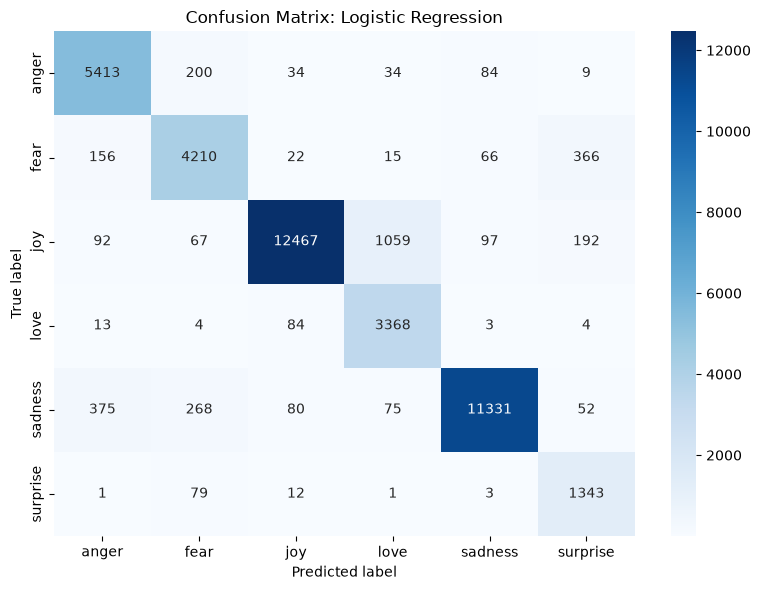

In [ ]:
# Use the best validation model to make final predictions on the test set.
test_predictions = best_model.predict(X_test)

# Print precision, recall, and F1-score for each emotion class.
print(f"{best_model_name} test performance:")
print(classification_report(y_test, test_predictions))

# Build a confusion matrix to see which emotions are confused with each other.
labels_order = sorted(df["label"].unique())
confusion = confusion_matrix(y_test, test_predictions, labels=labels_order)
confusion_df = pd.DataFrame(confusion, index=labels_order, columns=labels_order)

display(confusion_df)

# Plot the confusion matrix as a heatmap for easier visual analysis.
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


## 6. Week 9 -- Synthesis and Ethics

Analyze the misclassifications evident in your confusion matrix. Are certain emotions inherently ambiguous in short-form text? Draft a discussion on potential biases embedded within the training data, such as slang, dialectical variations, and cultural differences in emotional expression.

In [ ]:
# Copy the test data so each row can be compared with the model prediction.
error_analysis_df = test_df.copy()
error_analysis_df["predicted_label"] = test_predictions

# Keep only the examples where the model prediction was wrong.
misclassified_df = error_analysis_df[error_analysis_df["label"] != error_analysis_df["predicted_label"]].copy()

# Count the most common true-label to predicted-label mistakes.
top_confusions = (
    misclassified_df.groupby(["label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Display the most common error types and example mistakes.
display(top_confusions.head(10))
display(misclassified_df[["text", "clean_text", "label", "predicted_label"]].head(15))


,label,predicted_label,count
12,joy,love,1059
20,sadness,anger,375
9,fear,surprise,366
21,sadness,fear,268
0,anger,fear,200
14,joy,surprise,192
5,fear,anger,156
13,joy,sadness,97
10,joy,anger,92
3,anger,sadness,84


,text,clean_text,label,predicted_label
375134,i feel agitated the professor who baracaded th...,feel agitated professor baracaded door impress...,anger,fear
375135,i think im scared to feel like a divine loving...,think im scared feel like divine loving creati...,joy,love
375149,i attract wrong men and how i unconsciously se...,attract wrong men unconsciously seek approval ...,joy,love
375153,i felt as if nobody cared i was alone in my ro...,felt nobody cared alone room friends talking g...,sadness,anger
375173,i feel like lionels tortured in the cabin plot...,feel like lionels tortured cabin plot got chea...,fear,anger
375181,i don t feel i am doing a disservice to my rel...,feel disservice religion marriage supporting g...,joy,love
375185,i hope you will put all your political views a...,hope put political views judgments aside liste...,joy,love
375203,i mean previouslies are always up for speculat...,mean previouslies always speculation whatnot s...,joy,love
375231,i can afford the euros it just makes me feel r...,afford euros makes feel really insecure like k...,fear,sadness
375234,i think i need to start actually going to more...,think need start actually going shows buying t...,love,joy


### Error analysis

The best baseline model was Logistic Regression with TF-IDF features. On the test set, it reached about 91% accuracy, 0.88 macro F1, and 0.92 weighted F1. The weighted F1 is higher than macro F1 because the larger classes, especially `joy` and `sadness`, are predicted more reliably than the smaller classes such as `surprise` and `love`.

The strongest classes were `sadness`, `joy`, and `anger`. Their F1 scores were approximately 0.95, 0.93, and 0.92. The weakest class was `surprise`, with an F1 score around 0.79. This makes sense because surprise can overlap with fear, joy, or anger depending on context, and it also has the smallest number of examples in the dataset.

The confusion matrix shows several important error patterns. The model often confused `joy` with `love`, which is reasonable because many positive emotional phrases contain similar words. It also confused `fear` with `surprise`, likely because both emotions can describe sudden, uncertain, or intense reactions. Some `sadness` examples were predicted as `anger` or `fear`, suggesting that short text can express multiple negative emotions at once. These mistakes show that emotion labels are not always cleanly separated in short-form text.

### Ethics and bias discussion

This model should not be treated as a perfect detector of a person's true emotional state. It only learns patterns from labeled text, and those labels may reflect the assumptions of the dataset creators. Short messages often lack context, sarcasm, tone of voice, cultural background, and personal history, all of which affect how emotion should be interpreted.

The training data may also contain bias. Certain slang, dialects, or cultural styles of emotional expression may be underrepresented. If the dataset mostly reflects one online community or demographic group, the model may work worse for people who write differently. This is especially important for emotion recognition because mistakes could be harmful if used in mental health, education, hiring, or disciplinary settings.

A responsible use of this model would be as a research or exploratory tool, not as a final decision-maker. The results should be reported with uncertainty, and future work should test performance across different writing styles, communities, and datasets.

## 7. Week 10 -- Final Deliverables

Prepare your final research paper or poster and your presentation. Ensure your NLP pipeline (tokenization, vectorization) and final evaluation metrics are clearly documented and understandable to a non-technical audience.